# Unemployment Analysis in India (2019-2020)
### CodeAlpha Data Science Internship - Task 2

This notebook analyzes unemployment rate trends across Indian states, comparing rural vs. urban areas,
examining the impact of the COVID-19 lockdown, and identifying regional and seasonal patterns.

Datasets used:
- `Unemployment_in_India.csv`: state and area (Rural/Urban) level data, May 2019 to Jun 2020
- `Unemployment_Rate_upto_11_2020.csv`: state and zone level data with geo-coordinates, Jan to Oct 2020


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
pd.set_option('display.max_columns', None)


## 2. Load & Clean the Data

Both files have extra whitespace in their column names and string values. We strip whitespace,
parse the `Date` column, rename columns to be code-friendly, and drop fully-empty rows.

In [2]:
df1 = pd.read_csv('1786245315512_Unemployment_in_India.csv')
df1.columns = df1.columns.str.strip()
df1 = df1.dropna().copy()

for c in df1.columns:
    if df1[c].dtype == object or str(df1[c].dtype) == 'str':
        df1[c] = df1[c].astype(str).str.strip()

df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%Y')
df1 = df1.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})
df1['Month'] = df1['Date'].dt.month_name()
df1['Year'] = df1['Date'].dt.year

print(f"Shape: {df1.shape}")
print(f"Date range: {df1['Date'].min().date()} to {df1['Date'].max().date()}")
df1.head()


Shape: (740, 9)
Date range: 2019-05-31 to 2020-06-30


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019


In [3]:
df2 = pd.read_csv('1786245336868_Unemployment_Rate_upto_11_2020.csv')
df2.columns = df2.columns.str.strip()

for c in df2.columns:
    if df2[c].dtype == object or str(df2[c].dtype) == 'str':
        df2[c] = df2[c].astype(str).str.strip()

df2['Date'] = pd.to_datetime(df2['Date'], format='%d-%m-%Y')
df2 = df2.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region.1': 'Zone'
})

print(f"Shape: {df2.shape}")
print(f"Date range: {df2['Date'].min().date()} to {df2['Date'].max().date()}")
df2.head()


Shape: (267, 9)
Date range: 2020-01-31 to 2020-10-31


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Zone,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


Note on missing data: the raw `Unemployment_in_India.csv` file contained 28 completely empty rows
(no region, date, or values) which were dropped during cleaning. `Unemployment_Rate_upto_11_2020.csv` had
no missing values.

In [4]:
print("Missing values in df1:")
print(df1.isnull().sum())
print("\nMissing values in df2:")
print(df2.isnull().sum())
print(f"\nStates covered in df1: {df1['Region'].nunique()}")
print(f"Zones covered in df2: {df2['Zone'].unique().tolist()}")


Missing values in df1:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Month                        0
Year                         0
dtype: int64

Missing values in df2:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Zone                         0
longitude                    0
latitude                     0
dtype: int64

States covered in df1: 28
Zones covered in df2: ['South', 'Northeast', 'East', 'West', 'North']


## 3. Descriptive Statistics

In [5]:
df1[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe()


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## 4. National Unemployment Trend Over Time

Averaging across all states shows the overall trajectory of unemployment in India through the period,
with the COVID-19 lockdown window (25 March to 31 May 2020) highlighted.

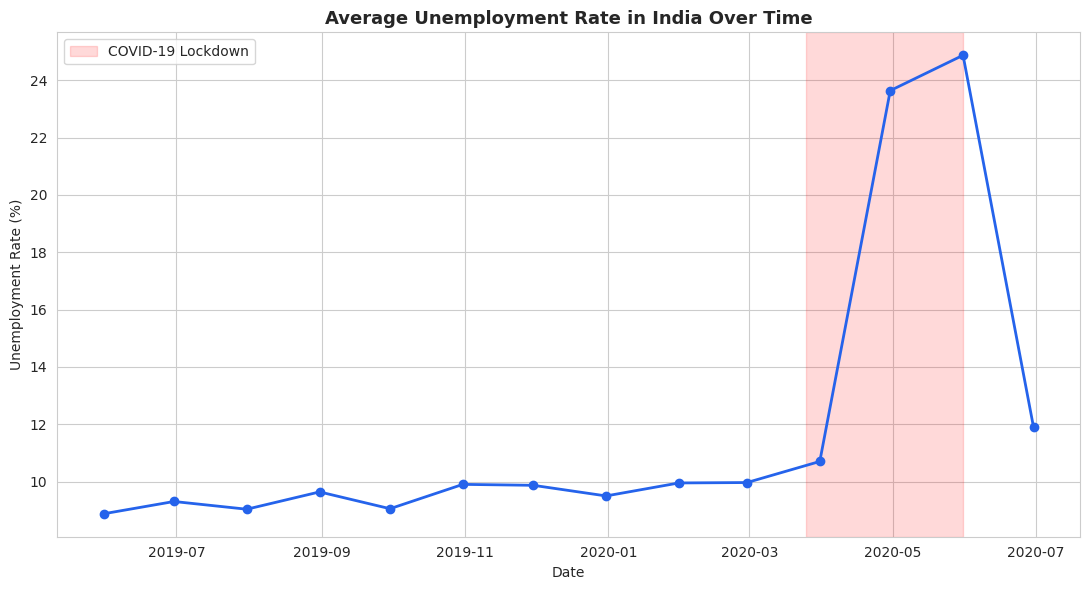

In [6]:
national_trend = df1.groupby('Date')['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots()
ax.plot(national_trend['Date'], national_trend['Unemployment_Rate'], marker='o', color='#2563eb', linewidth=2)
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='red', alpha=0.15, label='COVID-19 Lockdown')
ax.set_title('Average Unemployment Rate in India Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()


Observation: unemployment holds fairly steady (roughly 7 to 9%) through 2019 and early 2020, then spikes
sharply in April 2020, coinciding exactly with the national lockdown, before beginning to recover by June 2020.

## 5. Rural vs. Urban Unemployment

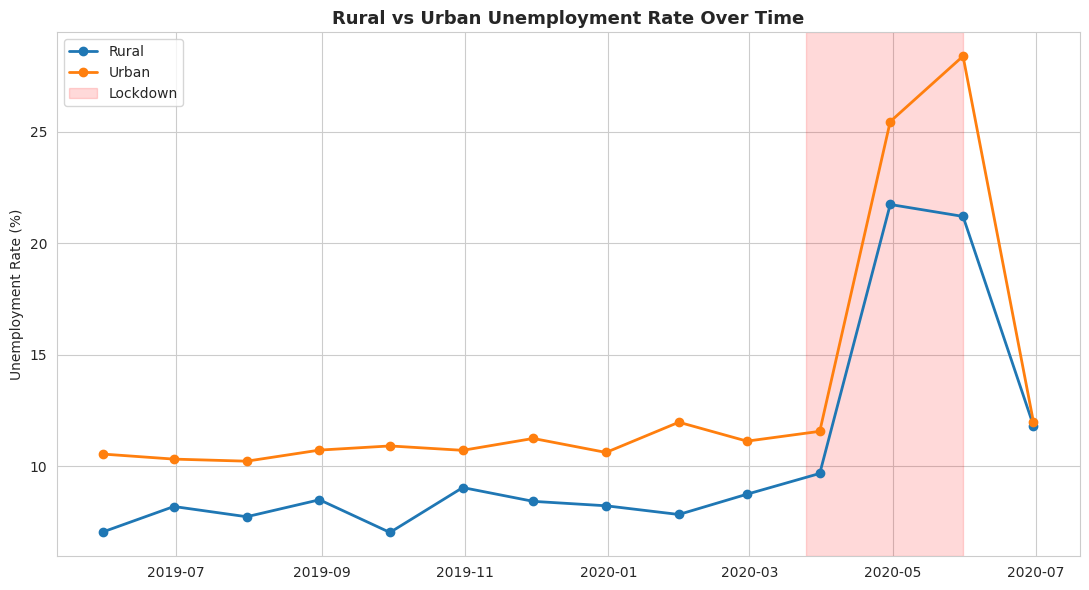

In [7]:
ru_trend = df1.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots()
for area, grp in ru_trend.groupby('Area'):
    ax.plot(grp['Date'], grp['Unemployment_Rate'], marker='o', label=area, linewidth=2)
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='red', alpha=0.15, label='Lockdown')
ax.set_title('Rural vs Urban Unemployment Rate Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()


Observation: urban areas consistently run a slightly higher baseline unemployment rate than rural areas,
but both segments spike during the lockdown. Urban unemployment jumps more sharply, likely reflecting the
concentration of service-sector and informal urban jobs disrupted by lockdown restrictions.

## 6. States with the Highest Average Unemployment

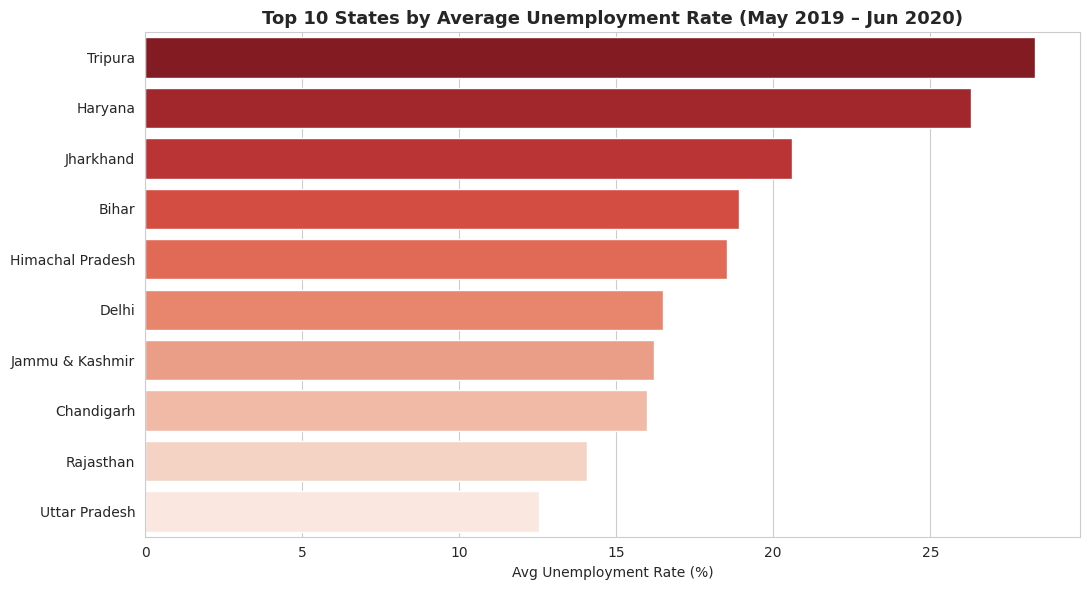

In [8]:
state_avg = df1.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(x=state_avg.values, y=state_avg.index, hue=state_avg.index, palette='Reds_r', legend=False, ax=ax)
ax.set_title('Top 10 States by Average Unemployment Rate (May 2019 – Jun 2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Unemployment Rate (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 7. Impact of COVID-19 on Unemployment

Splitting the data into a "pre-COVID" period (before April 2020) and a "COVID period" (April 2020 onward)
lets us directly compare the distributions.

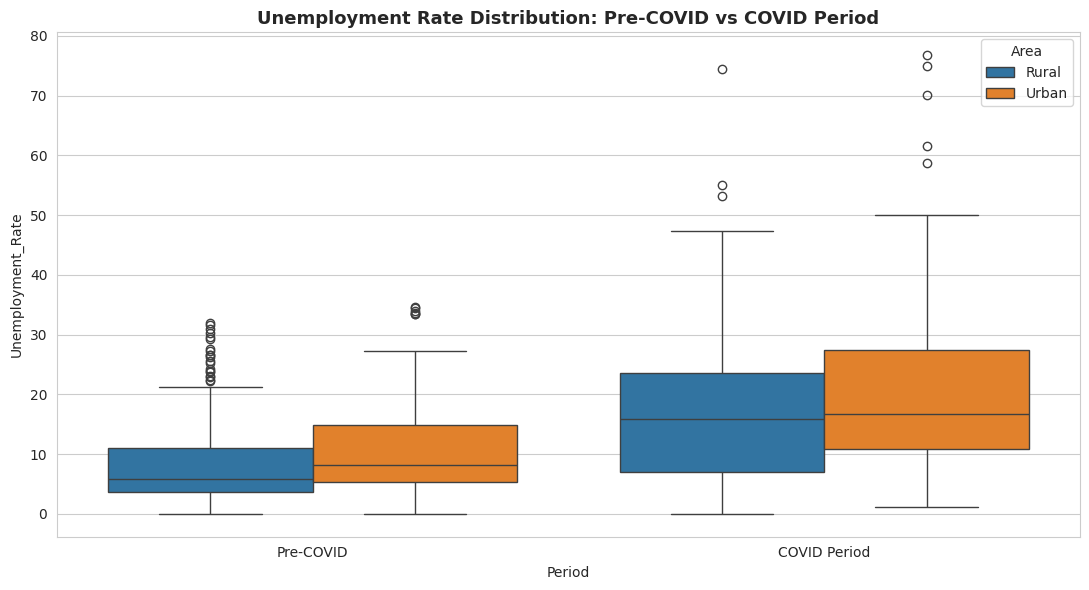

Pre-COVID average unemployment rate:  9.61%
COVID-period average unemployment rate: 20.19%
Increase: +10.58 percentage points (110% relative increase)

Peak unemployment: Puducherry (Urban) hit 76.74% in April 2020


In [9]:
df1['Period'] = np.where(df1['Date'] < '2020-04-01', 'Pre-COVID', 'COVID Period')

fig, ax = plt.subplots()
sns.boxplot(data=df1, x='Period', y='Unemployment_Rate', hue='Area', ax=ax)
ax.set_title('Unemployment Rate Distribution: Pre-COVID vs COVID Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pre = df1.loc[df1['Period'] == 'Pre-COVID', 'Unemployment_Rate'].mean()
during = df1.loc[df1['Period'] == 'COVID Period', 'Unemployment_Rate'].mean()
peak_row = df1.loc[df1['Unemployment_Rate'].idxmax()]

print(f"Pre-COVID average unemployment rate:  {pre:.2f}%")
print(f"COVID-period average unemployment rate: {during:.2f}%")
print(f"Increase: +{during - pre:.2f} percentage points ({(during/pre - 1)*100:.0f}% relative increase)")
print(f"\nPeak unemployment: {peak_row['Region']} ({peak_row['Area']}) hit {peak_row['Unemployment_Rate']}% in {peak_row['Date'].strftime('%B %Y')}")


## 8. Zone-Wise Unemployment (Jan-Oct 2020)

Using the second dataset, which groups states into geographic zones, we can see how the impact varied
regionally across the country.

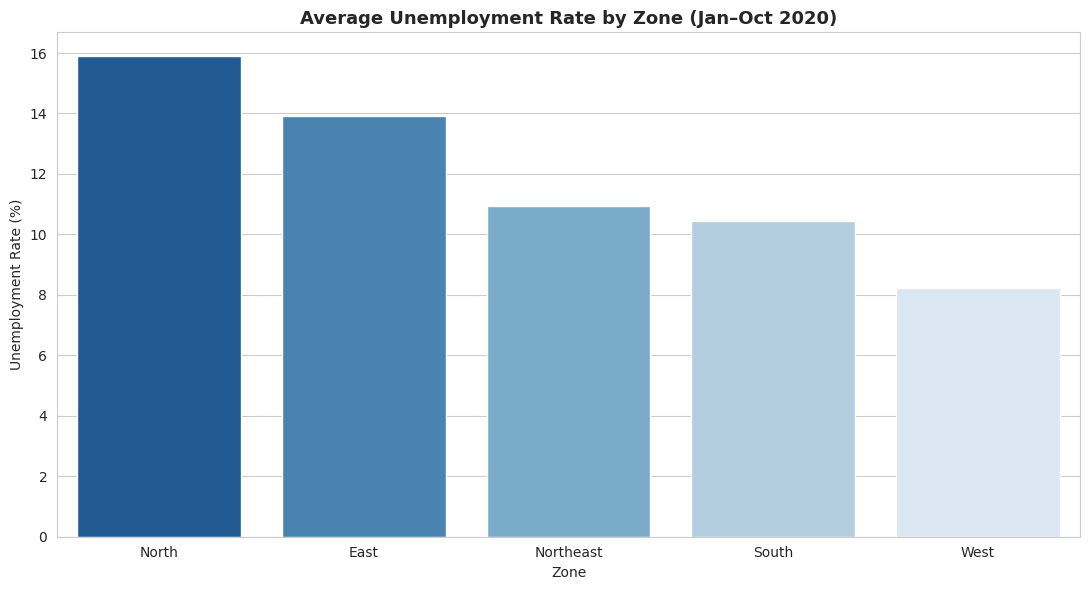

In [10]:
zone_avg = df2.groupby('Zone')['Unemployment_Rate'].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=zone_avg.index, y=zone_avg.values, hue=zone_avg.index, palette='Blues_r', legend=False, ax=ax)
ax.set_title('Average Unemployment Rate by Zone (Jan–Oct 2020)', fontsize=13, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_xlabel('Zone')
plt.tight_layout()
plt.show()


## 9. State x Month Heatmap

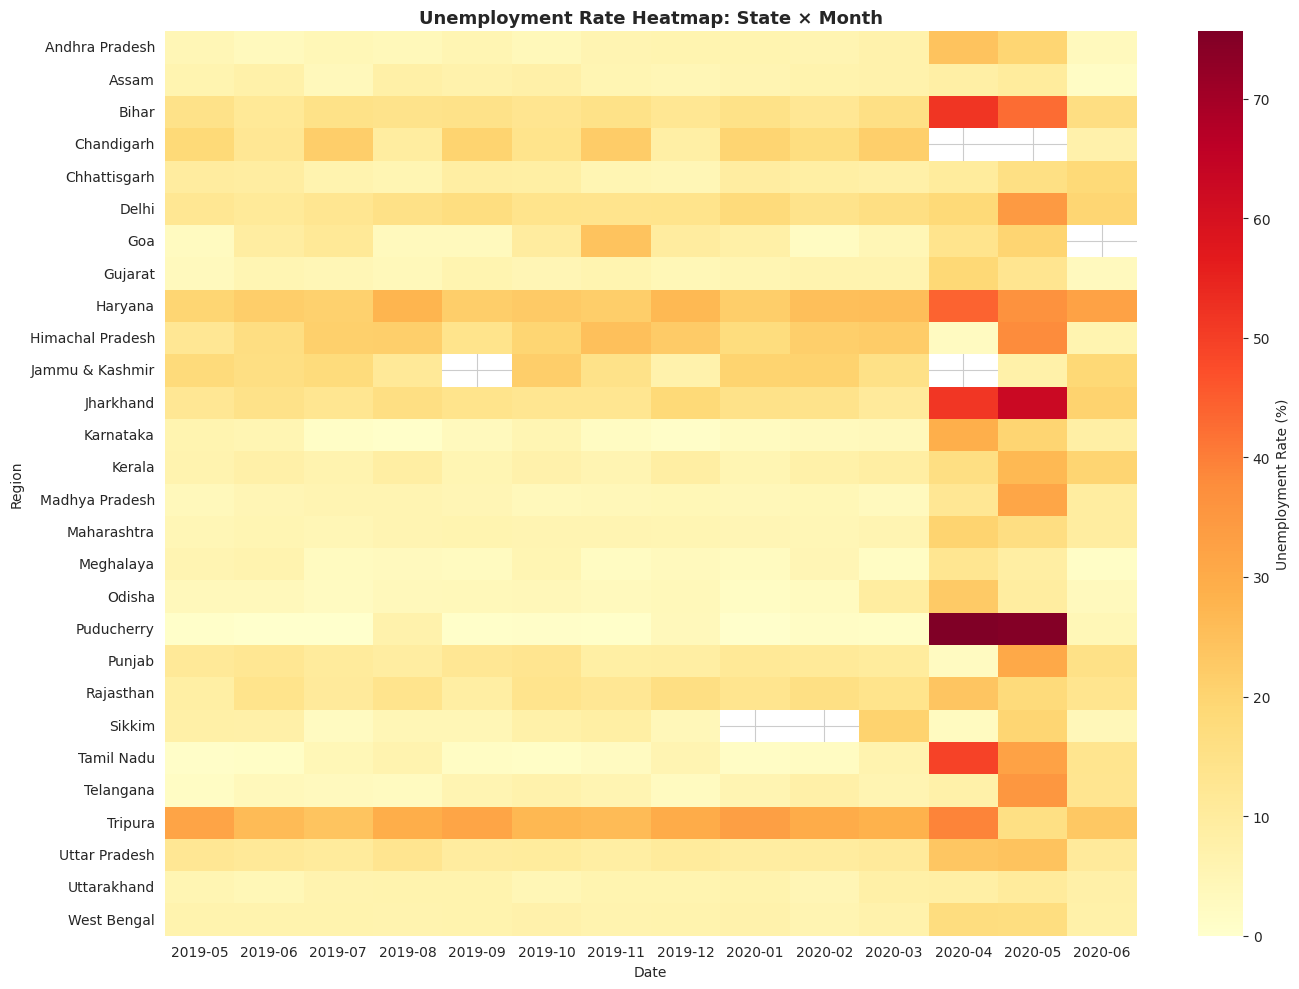

In [11]:
pivot = df1.pivot_table(index='Region', columns=df1['Date'].dt.strftime('%Y-%m'), values='Unemployment_Rate')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Unemployment Rate (%)'})
ax.set_title('Unemployment Rate Heatmap: State × Month', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Observation: the April-May 2020 columns light up sharply red across almost every state, confirming the
lockdown's nationwide impact rather than a regional anomaly. A few states (e.g. Puducherry, Tripura, Bihar,
Haryana) show particularly extreme spikes.

## 10. Correlation Between Key Indicators

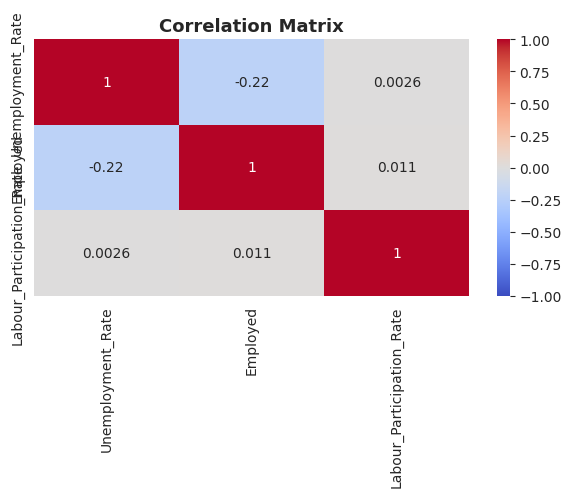

In [12]:
corr_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df1[corr_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Observation: unemployment rate and labour participation rate show a mild negative relationship.
Periods with more people actively seeking work sometimes coincide with slightly lower measured unemployment,
though the relationship is weak. Employed count and labour participation rate are moderately positively
correlated, as expected.

## 11. Key Insights & Policy Implications

1. COVID-19 caused a severe, sudden shock. National average unemployment more than doubled between the
   pre-COVID period and April-June 2020, jumping from roughly 9 to 10% to over 20% on average, with some states
   and urban areas spiking above 70% in April 2020.
2. Urban areas were hit harder than rural areas during the lockdown, likely due to the concentration of
   informal, service-sector, and gig-economy jobs in cities that were directly halted by movement restrictions.
3. The shock was nationwide, not regional. The state x month heatmap shows nearly every state affected in
   April-May 2020, though a handful of states experienced disproportionately extreme spikes.
4. Recovery began by June 2020 as lockdown restrictions eased, though rates had not returned to pre-COVID
   baselines by the end of the observed data.
5. Policy implications: the data supports the case for targeted urban employment relief programs (similar
   in spirit to India's rural employment guarantee schemes) during future large-scale disruptions, and for
   monitoring high-volatility states more closely for early-warning signs of economic distress.

Note: unemployment rate data can have measurement noise at the state level in smaller states/UTs (e.g. Puducherry, Tripura). The extreme spikes there should be read as directional rather than precise.